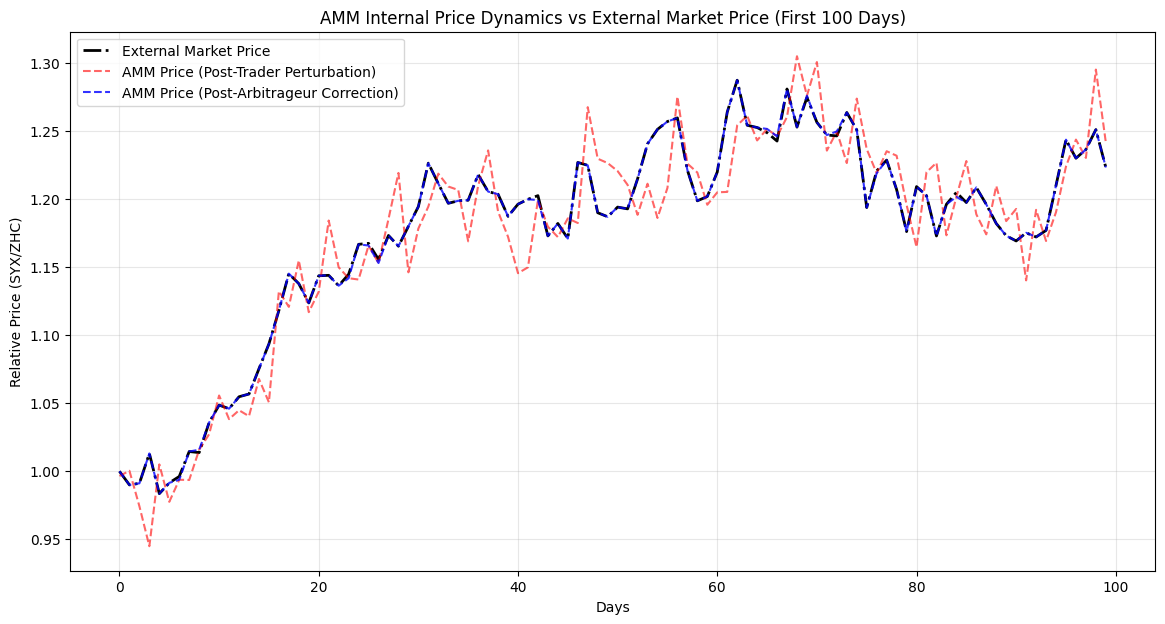

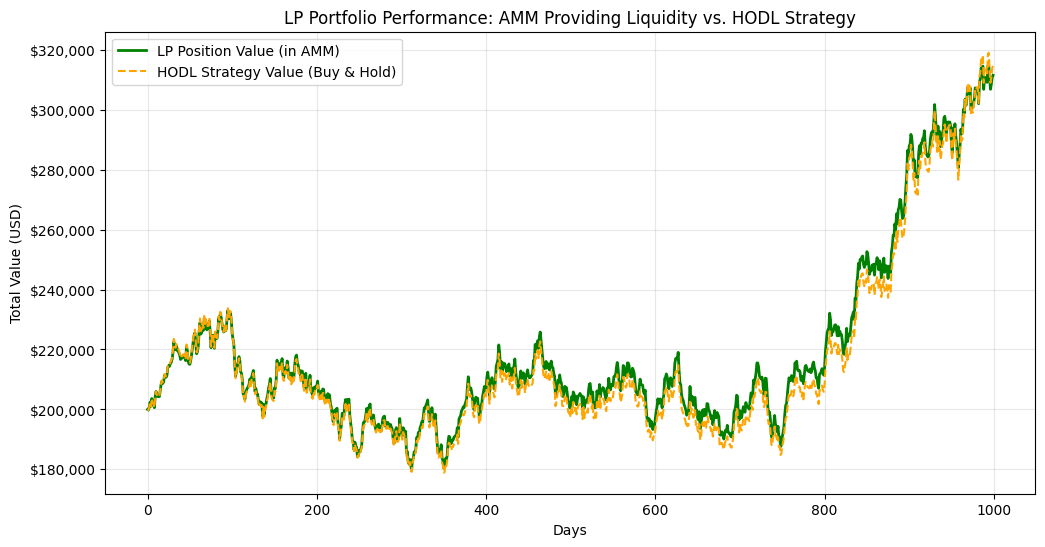

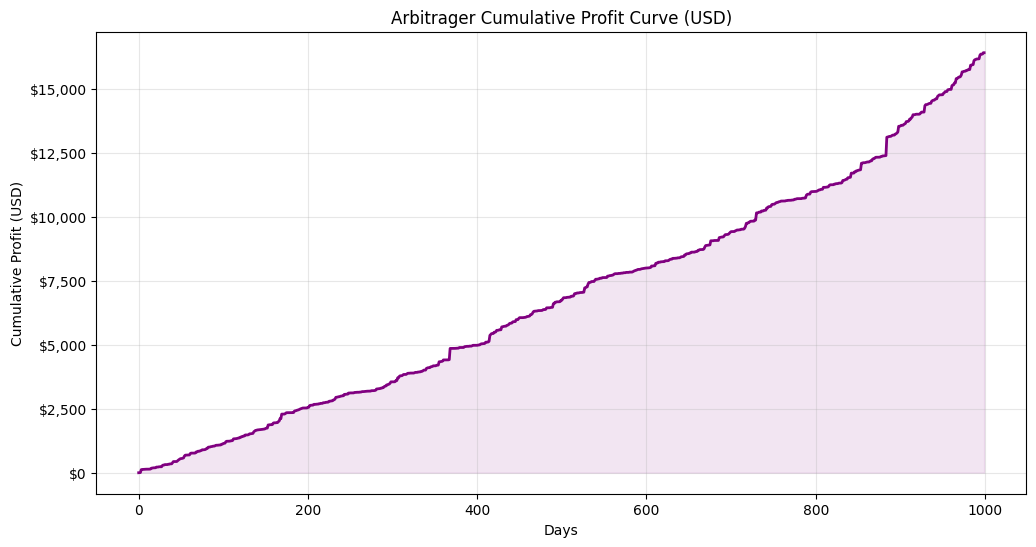

LP Unrealized P&L (USD): $111,504.26
LP Impermanent Loss (USD): $-3,100.88
Arbitrager Total Profit (USD): $16,399.05


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from market import Market
from contract import AMMContract
from market_entities import LP, Trader, Arbitrager

def run_simulation():
    days = 1000
    initial_syx = 100000.0
    initial_zhc = 100000.0
    
    # 初始化市场、合约与角色
    market = Market(initial_px=1.0, initial_py=1.0, mu_x=0.05, mu_y=0.03, 
                    sigma_x=0.4, sigma_y=0.1, rho=0.3, days=days)
    contract = AMMContract(x_init=initial_syx, y_init=initial_zhc, fee=0.003)
    lp = LP(initial_syx, initial_zhc)
    trader = Trader()
    arbitrager = Arbitrager()
    
    records = []
    cumulative_arb_profit_usd = 0.0

    for day in range(days):
        current_market_price = market.get_price(day)
        abs_px, abs_py = market.get_absolute_prices(day)
        
        # 【修正点 1】：在 Trader 交易前，获取当前的内部价格
        price_pre_trade = contract.get_internal_price()
        
        # 1. 噪音交易者进行随机交易
        trader.random_trade(contract)
        
        # 【修正点 2】：在 Trader 交易后、套利前，获取被扰动后的价格
        price_post_trade = contract.get_internal_price()
        
        # 2. 套利者发现价差并修正
        prev_arb_zhc = arbitrager.cumulative_profit_zhc
        arbitrager.execute_arbitrage(contract, current_market_price)
        daily_arb_profit_zhc = arbitrager.cumulative_profit_zhc - prev_arb_zhc
        
        # USD 利润折算
        daily_arb_profit_usd = daily_arb_profit_zhc * abs_py
        cumulative_arb_profit_usd += daily_arb_profit_usd
        
        # 计算 LP 当日仓位 USD 价值
        current_lp_value_usd = (contract.x * abs_px) + (contract.y * abs_py)
        hodl_value_usd = (initial_syx * abs_px) + (initial_zhc * abs_py)
        
        # 3. 记录每日数据
        records.append({
            'Day': day,
            'Market_Price_SYX_USD': abs_px,
            'Market_Price_ZHC_USD': abs_py,
            'Market_Relative_Price': current_market_price,
            'AMM_Price_Pre': price_pre_trade,
            'AMM_Price_Post_Trader': price_post_trade,
            'AMM_Price_Post_Arb': contract.get_internal_price(),
            'Pool_SYX': contract.x,
            'Pool_ZHC': contract.y,
            'Arbitrageur_Profit_USD': cumulative_arb_profit_usd,
            'LP_Position_USD': current_lp_value_usd,
            'LP_HODL_Value_USD': hodl_value_usd
        })
        
    df = pd.DataFrame(records)
    
    # 期末结算逻辑
    final_px, final_py = market.get_absolute_prices(days - 1)
    initial_value_usd = initial_syx * 1.0 + initial_zhc * 1.0 
    current_value_usd = (contract.x * final_px) + (contract.y * final_py)
    hold_value_usd = (initial_syx * final_px) + (initial_zhc * final_py)
    
    lp_unrealized_pnl_usd = current_value_usd - initial_value_usd
    lp_impermanent_loss_usd = current_value_usd - hold_value_usd
    
    return df, lp_unrealized_pnl_usd, lp_impermanent_loss_usd

def plot_price_dynamics(df):
    """图 1: AMM 价格与市场价格的偏离和修正过程"""
    # 建议只截取前 100 天，否则 1000 天的线会挤在一起看不清扰动细节
    df_subset = df.head(100) 
    
    plt.figure(figsize=(14, 7))
    plt.plot(df_subset['Day'], df_subset['Market_Relative_Price'], label='External Market Price', color='black', linewidth=2, linestyle='-.')
    plt.plot(df_subset['Day'], df_subset['AMM_Price_Post_Trader'], label='AMM Price (Post-Trader Perturbation)', color='red', alpha=0.6, linestyle='--')
    plt.plot(df_subset['Day'], df_subset['AMM_Price_Post_Arb'], label='AMM Price (Post-Arbitrageur Correction)', color='blue', alpha=0.8, linestyle='--')
    
    plt.title('AMM Internal Price Dynamics vs External Market Price (First 100 Days)')
    plt.xlabel('Days')
    plt.ylabel('Relative Price (SYX/ZHC)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

def plot_lp_performance(df):
    """图 2: LP 仓位绩效走势 (USD)"""
    plt.figure(figsize=(12, 6))
    plt.plot(df['Day'], df['LP_Position_USD'], label='LP Position Value (in AMM)', color='green', linewidth=2)
    plt.plot(df['Day'], df['LP_HODL_Value_USD'], label='HODL Strategy Value (Buy & Hold)', color='orange', linestyle='--')
    
    plt.title('LP Portfolio Performance: AMM Providing Liquidity vs. HODL Strategy')
    plt.xlabel('Days')
    plt.ylabel('Total Value (USD)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.gca().get_yaxis().set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('${x:,.0f}'))
    plt.show()

def plot_arbitrager_profit_curve(df):
    """图 3: 套利者累计利润曲线 (USD)"""
    plt.figure(figsize=(12, 6))
    plt.plot(df['Day'], df['Arbitrageur_Profit_USD'], color='purple', linewidth=2)
    plt.fill_between(df['Day'], df['Arbitrageur_Profit_USD'], color='purple', alpha=0.1)
    
    plt.title('Arbitrager Cumulative Profit Curve (USD)')
    plt.xlabel('Days')
    plt.ylabel('Cumulative Profit (USD)')
    plt.grid(True, alpha=0.3)
    plt.gca().get_yaxis().set_major_formatter(plt.matplotlib.ticker.StrMethodFormatter('${x:,.0f}'))
    plt.show()

# ================= 运行调用部分 =================

# 1. 运行模拟
df_results, lp_pnl_usd, lp_il_usd = run_simulation()

# 2. 调用图表
plot_price_dynamics(df_results) 
plot_lp_performance(df_results)
plot_arbitrager_profit_curve(df_results)

# 3. 输出分析结果
print(f"LP Unrealized P&L (USD): ${lp_pnl_usd:,.2f}")
print(f"LP Impermanent Loss (USD): ${lp_il_usd:,.2f}")
print(f"Arbitrager Total Profit (USD): ${df_results['Arbitrageur_Profit_USD'].iloc[-1]:,.2f}")

# df_results.to_excel('amm_simulation_usd_results.xlsx', index=False)